In [1]:
# load from drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_dir = Path("/content/drive/MyDrive/XFoodRec_Project_Data/raw")
persona_path = data_dir / "personas.json"
recommendation_path = data_dir / "recommendations.json"
recipe_path = data_dir / "recipes.parquet"

In [3]:
with open(persona_path, "r", encoding="utf-8") as f:
    personas = json.load(f)

with open(recommendation_path, "r", encoding="utf-8") as f:
    recommendations = json.load(f)

recipes = pd.read_parquet(recipe_path)

### Inspect source data

In [4]:
print("personas")
print("type:", type(personas))
print("length:", len(personas))

print("\nrecommendations")
print("type:", type(recommendations))
print("length:", len(recommendations))

print("\nrecipes")
print("type:", type(recipes))
print("shape:", recipes.shape)

personas
type: <class 'list'>
length: 40

recommendations
type: <class 'list'>
length: 40

recipes
type: <class 'pandas.core.frame.DataFrame'>
shape: (702, 31)


In [5]:
if isinstance(personas, dict):
    print("persona keys:", personas.keys())
else:
    print("first persona:")
    print(personas[0])

first persona:
{'id': 'user_01', 'description': 'A vegan competitive bodybuilder focused on lean bulking without soy overload.', 'profile': {'age': 28, 'gender': 'Male', 'height': 182.0, 'weight': 84.0, 'activityLevel': 'very_active', 'dietary_goal': 'Muscle Gain', 'dietaryProfile': {'dietaryRestrictions': {'selected': ['Vegan'], 'other': 'High-protein, prefers low-soy options'}, 'foodAllergies': {'selected': [], 'other': ''}, 'healthConditions': {'selected': [], 'other': ''}}, 'likedIngredients': ['Seitan', 'Lentils', 'Chickpeas', 'Hemp seeds'], 'dislikedIngredients': ['Mushrooms', 'Eggplant'], 'favoriteCuisines': ['Middle Eastern', 'Indian', 'Mediterranean']}}


In [6]:
if isinstance(recommendations, dict):
    print("recommendation keys:", recommendations.keys())
else:
    print("first recommendation:")
    print(recommendations[0])

first recommendation:
{'persona': {'id': 'user_01', 'description': 'A vegan competitive bodybuilder focused on lean bulking without soy overload.', 'profile': {'age': 28, 'gender': 'Male', 'height': 182.0, 'weight': 84.0, 'activityLevel': 'very_active', 'dietary_goal': 'Muscle Gain', 'dietaryProfile': {'dietaryRestrictions': {'selected': ['Vegan'], 'other': 'High-protein, prefers low-soy options'}, 'foodAllergies': {'selected': [], 'other': ''}, 'healthConditions': {'selected': [], 'other': ''}}, 'likedIngredients': ['Seitan', 'Lentils', 'Chickpeas', 'Hemp seeds'], 'dislikedIngredients': ['Mushrooms', 'Eggplant'], 'favoriteCuisines': ['Middle Eastern', 'Indian', 'Mediterranean']}}, 'recommendations': [{'recipe_id': '81968', 'title': 'Chickpeas With Spinach (Greek)', 'explanation': 'Chickpeas With Spinach (Greek) is a fantastic choice packed with protein, aligning perfectly with your muscle gain goal. The inclusion of chickpeas and spinach not only satisfies your taste for legumes but a

In [7]:
display(recipes.head())

print("\nrecipe columns:")
print(recipes.columns.tolist())

,recipe_id,title,recipe_url,image_url,ingredients,ingredients_title,tags,calories_per_serving [cal],calories_per_100g [cal],caloriesfromfat_per_serving [cal],...,dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score
0,113861,My Own Cube Steak and Gravy,https://www.food.com/recipe/my-own-cube-steak-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('cubed steak (4-6 pieces)', '2 time(s)...","[cubed steak (4-6 pieces), oil, butter, flour,...","[Moderate Calorie, Vegetarian]",500.5,175.6,216,...,0.8,0.3,0.8,0.3,48.0,16.8,0.266834,0.250,0.00,3.6
1,111212,Our Secret Sirloin Steak,https://www.food.com/recipe/our-secret-sirloin...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('Lea & Perrins Worcestershire Sauce, pl...","[Lea & Perrins Worcestershire Sauce, Lea & Per...","[Moderate Calorie, Vegetarian]",823.6,320.5,502,...,0.4,0.2,3.4,1.3,69.5,27.0,0.186863,0.250,0.00,2.9
2,497021,Mile-High Cabbage Pie #5FIX,https://www.food.com/recipe/mile-high-cabbage-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('lean ground beef', '1 1/2 time(s) lbs ...","[lean beef, coleslaw mix (cabbage and carrots)...",[Moderate Calorie],803.0,221.2,298,...,7.0,1.9,10.7,2.9,48.7,13.4,0.266693,0.250,0.00,3.6
3,31184,15 Minute Shrimp Scampi,https://www.food.com/recipe/15-minute-shrimp-s...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('extra virgin olive oil', '0.5 time(s) ...","[extra virgin olive oil, onion, cloves garlic,...",[Moderate Calorie],596.2,342.6,416,...,0.7,0.4,2.2,1.3,26.7,15.3,0.169814,0.250,0.00,2.7
4,71739,Easy Garlic Rice,https://www.food.com/recipe/easy-garlic-rice-7...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('olive oil', '2 time(s) tablespoons ')...","[olive oil, onion, garlic cloves, long grain r...",[Moderate Calorie],264.2,190.1,70,...,1.3,0.9,1.6,1.2,6.3,4.5,0.222165,0.625,0.25,5.2



recipe columns:
['recipe_id', 'title', 'recipe_url', 'image_url', 'ingredients', 'ingredients_title', 'tags', 'calories_per_serving [cal]', 'calories_per_100g [cal]', 'caloriesfromfat_per_serving [cal]', 'caloriesfromfat_per_100g [cal]', 'totalfat_per_serving [g]', 'totalfat_per_100g [g]', 'saturatedfat_per_serving [g]', 'saturatedfat_per_100g [g]', 'cholesterol_per_serving [mg]', 'cholesterol_per_100g [mg]', 'sodium_per_serving [mg]', 'sodium_per_100g [mg]', 'totalcarbohydrate_per_serving [g]', 'totalcarbohydrate_per_100g [g]', 'dietaryfiber_per_serving [g]', 'dietaryfiber_per_100g [g]', 'sugars_per_serving [g]', 'sugars_per_100g [g]', 'protein_per_serving [g]', 'protein_per_100g [g]', 'who_score', 'fsa_score', 'nutri_score', 'health_score']


#### Check Persona Data

In [8]:
personas_df = pd.json_normalize(personas)

print(personas_df.shape)
display(personas_df.head())

print(personas_df.columns.tolist())

(40, 17)


,id,description,profile.age,profile.gender,profile.height,profile.weight,profile.activityLevel,profile.dietary_goal,profile.dietaryProfile.dietaryRestrictions.selected,profile.dietaryProfile.dietaryRestrictions.other,profile.dietaryProfile.foodAllergies.selected,profile.dietaryProfile.foodAllergies.other,profile.dietaryProfile.healthConditions.selected,profile.dietaryProfile.healthConditions.other,profile.likedIngredients,profile.dislikedIngredients,profile.favoriteCuisines
0,user_01,A vegan competitive bodybuilder focused on lea...,28,Male,182.0,84.0,very_active,Muscle Gain,[Vegan],"High-protein, prefers low-soy options",[],,[],,"[Seitan, Lentils, Chickpeas, Hemp seeds]","[Mushrooms, Eggplant]","[Middle Eastern, Indian, Mediterranean]"
1,user_02,A type 1 diabetic with a severe tree-nut aller...,34,Female,168.0,67.0,moderately_active,Medical Management,[Low Carb],Counts carbs precisely; prefers low-GI foods,[Tree Nuts],Avoids cross-contamination,[Diabetes (Type 1)],,"[Chicken, Greek yogurt, Broccoli, Berries]","[Sweetened cereals, Fruit juice]","[American, Mediterranean]"
2,user_03,A low-budget student with lactose intolerance ...,20,Non-binary,172.0,92.0,lightly_active,Weight Loss,[Lactose-Free],Very budget-constrained; batch-cooks,[],,[],,"[Rice, Beans, Frozen vegetables, Canned tuna]","[Cottage cheese, Cream sauces]","[Mexican, Asian]"
3,user_04,A pregnant vegetarian with iron-deficiency ane...,31,Female,160.0,64.0,lightly_active,Medical Management,[Vegetarian],"Pregnant; prioritizes iron, folate, choline",[],,[Anemia],Iron-deficiency anemia,"[Eggs, Lentils, Spinach, Fortified cereal]","[Tofu, Beets]","[Mediterranean, Indian]"
4,user_05,A marathon runner with celiac disease optimizi...,26,Male,177.0,66.0,very_active,Energy Boost,[Gluten-Free],Endurance fueling; needs portable snacks,[],,[Celiac Disease],,"[Rice, Potatoes, Bananas, Oats (certified GF)]","[Wheat bread, Barley]","[Japanese, Mexican]"


['id', 'description', 'profile.age', 'profile.gender', 'profile.height', 'profile.weight', 'profile.activityLevel', 'profile.dietary_goal', 'profile.dietaryProfile.dietaryRestrictions.selected', 'profile.dietaryProfile.dietaryRestrictions.other', 'profile.dietaryProfile.foodAllergies.selected', 'profile.dietaryProfile.foodAllergies.other', 'profile.dietaryProfile.healthConditions.selected', 'profile.dietaryProfile.healthConditions.other', 'profile.likedIngredients', 'profile.dislikedIngredients', 'profile.favoriteCuisines']


In [9]:
personas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 17 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   40 non-null     object 
 1   description                                          40 non-null     object 
 2   profile.age                                          40 non-null     int64  
 3   profile.gender                                       40 non-null     object 
 4   profile.height                                       40 non-null     float64
 5   profile.weight                                       40 non-null     float64
 6   profile.activityLevel                                40 non-null     object 
 7   profile.dietary_goal                                 40 non-null     object 
 8   profile.dietaryProfile.dietaryRestrictions.selected  40 non-null     obj

In [10]:
personas_df.isna().sum()

,0
id,0
description,0
profile.age,0
profile.gender,0
profile.height,0
profile.weight,0
profile.activityLevel,0
profile.dietary_goal,0
profile.dietaryProfile.dietaryRestrictions.selected,0
profile.dietaryProfile.dietaryRestrictions.other,0


In [11]:
print("unique personas:", personas_df["id"].nunique())
print("duplicate ids:", personas_df["id"].duplicated().sum())

unique personas: 40
duplicate ids: 0


In [12]:
distribution_columns = {
    "Gender": "profile.gender",
    "Dietary Goal": "profile.dietary_goal",
    "Activity Level": "profile.activityLevel",
    "Dietary Restriction": "profile.dietaryProfile.dietaryRestrictions.selected",
    "Food Allergy": "profile.dietaryProfile.foodAllergies.selected",
    "Health Condition": "profile.dietaryProfile.healthConditions.selected"
}

persona_distribution = {}

for name, column in distribution_columns.items():
    values = personas_df[column]

    if values.apply(lambda x: isinstance(x, list)).all():
        values = values.explode()

    counts = values.value_counts()
    persona_distribution[name] = pd.Series(
        [f"{category}: {count}" for category, count in counts.items()]
    )

display(pd.DataFrame(persona_distribution).fillna(""))

,Gender,Dietary Goal,Activity Level,Dietary Restriction,Food Allergy,Health Condition
0,Female: 20,Medical Management: 14,lightly_active: 14,High Protein: 3,Tree Nuts: 2,Food Allergy: 2
1,Male: 19,Maintenance: 8,moderately_active: 13,Vegan: 2,Peanuts: 2,Diabetes (Type 1): 1
2,Non-binary: 1,Weight Loss: 7,sedentary: 7,Keto: 2,Milk: 2,Celiac Disease: 1
3,,Energy Boost: 6,very_active: 6,Lactose-Free: 2,Eggs: 2,Post-Surgery: 1
4,,Muscle Gain: 5,,Low Fiber: 2,Shellfish: 1,High Cholesterol: 1
5,,,,Low Sodium: 2,Wheat: 1,Anemia: 1
6,,,,Anti-Inflammatory: 2,Soy: 1,Kidney Disease: 1
7,,,,Low Fat: 2,Sesame: 1,GERD: 1
8,,,,Low Carb: 1,Apples: 1,IBS: 1
9,,,,Vegetarian: 1,,Autism Spectrum: 1


### Prepare recommendation records

In [13]:
recommendation_rows = []

for item in recommendations:
    persona_id = item["persona"]["id"]

    for rec in item["recommendations"]:
        recommendation_rows.append({
            "persona_id": persona_id,
            **rec
        })

recommendations_df = pd.DataFrame(recommendation_rows)

print(recommendations_df.shape)
display(recommendations_df.head())

(536, 6)


,persona_id,recipe_id,title,explanation,ingredients,nutrition
0,user_01,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...","{'calories': 310.2, 'protein': '13.3g', 'carbs..."
1,user_01,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...","{'calories': 307.1, 'protein': '17.6g', 'carbs..."
2,user_01,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...","{'calories': 204.5, 'protein': '10.3g', 'carbs..."
3,user_01,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...","{'calories': 154.2, 'protein': '5.8g', 'carbs'..."
4,user_01,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...","{'calories': 533.8, 'protein': '11.4g', 'carbs..."


In [14]:
recommendations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   persona_id   536 non-null    object
 1   recipe_id    536 non-null    object
 2   title        536 non-null    object
 3   explanation  536 non-null    object
 4   ingredients  536 non-null    object
 5   nutrition    536 non-null    object
dtypes: object(6)
memory usage: 25.3+ KB


In [15]:
print(recommendations_df.columns.tolist())

['persona_id', 'recipe_id', 'title', 'explanation', 'ingredients', 'nutrition']


In [16]:
personas_df["profile.dietaryProfile.dietaryRestrictions.selected"].explode().value_counts(dropna=False)

,count
profile.dietaryProfile.dietaryRestrictions.selected,
NaN,8
High Protein,3
Vegan,2
Keto,2
Lactose-Free,2
Low Fiber,2
Low Sodium,2
Anti-Inflammatory,2
Low Fat,2


In [17]:
rec_counts = recommendations_df.groupby("persona_id").size()

display(rec_counts.describe())

,0
count,40.000000
mean,13.400000
std,1.335895
min,10.000000
25%,12.750000
50%,13.500000
75%,14.000000
max,16.000000


In [18]:
display(rec_counts.sort_values())

,0
persona_id,
user_12,10
user_02,11
user_36,11
user_20,12
user_30,12
user_29,12
user_34,12
user_17,12
user_37,12


In [19]:
print("total recommendations:", len(recommendations_df))
print("personas:", recommendations_df["persona_id"].nunique())
print("unique recipes:", recommendations_df["recipe_id"].nunique())

total recommendations: 536
personas: 40
unique recipes: 173


In [20]:
duplicate_recs = recommendations_df.duplicated(
    subset=["persona_id", "recipe_id"],
    keep=False
)

print("duplicate recommendation rows:", duplicate_recs.sum())

duplicate recommendation rows: 89


In [21]:
display(
    recommendations_df.loc[
        duplicate_recs,
        ["persona_id", "recipe_id", "title", "explanation"]
    ].sort_values(["persona_id", "recipe_id"])
)

,persona_id,recipe_id,title,explanation
5,user_01,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
7,user_01,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
3,user_01,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
13,user_01,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
9,user_01,46221,Classic Black Beans and Rice,Classic Black Beans and Rice is a traditional ...
...,...,...,...,...
431,user_32,8594,Fried Rice,Fried Rice is a versatile dish that can be enj...
460,user_35,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
466,user_35,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
515,user_39,15344,Easy Weeknight Sloppy Joes,Easy Weeknight Sloppy Joes are a hearty option...


In [22]:
print(
    "unique persona-recipe pairs:",
    recommendations_df[
        ["persona_id", "recipe_id"]
    ].drop_duplicates().shape[0]
)

unique persona-recipe pairs: 484


### Recipe links

In [23]:
print(recommendations_df["recipe_id"].dtype)
print(recipes["recipe_id"].dtype)

object
int64


In [24]:
recommendations_df["recipe_id"] = recommendations_df["recipe_id"].astype(str)
recipes["recipe_id"] = recipes["recipe_id"].astype(str)

matched = recommendations_df["recipe_id"].isin(recipes["recipe_id"])

print("matched:", matched.sum())
print("unmatched:", (~matched).sum())
print("match rate:", matched.mean())

matched: 536
unmatched: 0
match rate: 1.0


In [25]:
nutrition_df = pd.json_normalize(recommendations_df["nutrition"])

display(nutrition_df.head())

,calories,protein,carbs,fat
0,310.2,13.3g,54.2g,6.2g
1,307.1,17.6g,51.1g,2.6g
2,204.5,10.3g,35.2g,3.0g
3,154.2,5.8g,18.9g,8.0g
4,533.8,11.4g,101.5g,11.2g


In [26]:
recommendations_df = pd.concat(
    [
        recommendations_df.drop(columns="nutrition"),
        nutrition_df.add_prefix("rec_")
    ],
    axis=1
)

In [27]:
merged_df = recommendations_df.merge(
    recipes,
    on="recipe_id",
    how="left",
    suffixes=("_rec", "_recipe")
)

print(merged_df.shape)
display(merged_df.head())

(536, 39)


,persona_id,recipe_id,title_rec,explanation,ingredients_rec,rec_calories,rec_protein,rec_carbs,rec_fat,title_recipe,...,dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score
0,user_01,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...",310.2,13.3g,54.2g,6.2g,Chickpeas With Spinach (Greek),...,12.6,3.1,5.1,1.3,13.3,3.3,0.275309,0.75,0.50,6.9
1,user_01,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...",307.1,17.6g,51.1g,2.6g,Refried Beans,...,17.4,7.9,1.8,0.8,17.6,8.0,0.349709,1.00,1.00,10.0
2,user_01,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...",204.5,10.3g,35.2g,3.0g,Egyptian Red Lentil Soup,...,12.0,10.6,3.6,3.2,10.3,9.1,0.261062,0.75,0.50,6.8
3,user_01,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...",154.2,5.8g,18.9g,8.0g,My Favorite Sauteed Kale,...,3.4,1.8,1.2,0.6,5.8,3.1,0.320405,0.75,0.50,7.4
4,user_01,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...",533.8,11.4g,101.5g,11.2g,Hearty Black Beans & Rice,...,14.1,2.8,8.3,1.6,11.4,2.2,0.266208,0.75,0.25,6.1


In [28]:
print(
    "recommendations without recipe data:",
    merged_df["title_recipe"].isna().sum()
)

recommendations without recipe data: 0


In [29]:
merged_df[
    [
        "title_rec",
        "rec_protein",
        "protein_per_serving [g]",
        "rec_calories",
        "calories_per_serving [cal]"
    ]
].head(20)

,title_rec,rec_protein,protein_per_serving [g],rec_calories,calories_per_serving [cal]
0,Chickpeas With Spinach (Greek),13.3g,13.3,310.2,310.2
1,Refried Beans,17.6g,17.6,307.1,307.1
2,Egyptian Red Lentil Soup,10.3g,10.3,204.5,204.5
3,My Favorite Sauteed Kale,5.8g,5.8,154.2,154.2
4,Hearty Black Beans & Rice,11.4g,11.4,533.8,533.8
5,Black Bean and Corn Salad,6.4g,6.4,159.6,159.6
6,Fried Cabbage,32.8g,32.8,1176.6,1176.6
7,Black Bean and Corn Salad,6.4g,6.4,159.6,159.6
8,Hummus,5.4g,5.4,144.8,144.8
9,Classic Black Beans and Rice,9.4g,9.4,298.4,298.4


### Build analysis table

In [30]:
analysis_rows = []
for block_index, item in enumerate(recommendations):
    for position, rec in enumerate(item["recommendations"], start=1):
        analysis_rows.append({
            **rec,
            "persona_id": item["persona"]["id"],
            "recommendation_position": position,
            "explanation_id": f"block_{block_index + 1:02d}_position_{position:02d}",
        })

explanations_df = pd.DataFrame(analysis_rows)
recipe_lookup = recipes.copy()
persona_lookup = personas_df.rename(columns={"id": "persona_id"}).copy()

#join-key types on copies, leaving source tables unchanged
explanations_df["recipe_id"] = explanations_df["recipe_id"].astype("string").str.strip()
recipe_lookup["recipe_id"] = recipe_lookup["recipe_id"].astype("string").str.strip()
explanations_df["persona_id"] = explanations_df["persona_id"].astype("string").str.strip()
persona_lookup["persona_id"] = persona_lookup["persona_id"].astype("string").str.strip()

assert recipe_lookup["recipe_id"].notna().all()
assert recipe_lookup["recipe_id"].ne("").all()
assert recipe_lookup["recipe_id"].is_unique, "Recipe IDs must be unique before a many-to-one merge."
assert persona_lookup["persona_id"].notna().all()
assert persona_lookup["persona_id"].is_unique

analysis_df = explanations_df.merge(
    recipe_lookup, on="recipe_id", how="left",
    suffixes=("_rec", "_recipe"), validate="many_to_one", indicator="recipe_match"
).merge(
    persona_lookup, on="persona_id", how="left",
    validate="many_to_one", indicator="persona_match"
)

print("analysis table shape:", analysis_df.shape)
print("recommendation rows retained:", len(analysis_df) == len(explanations_df))
display(analysis_df[["explanation_id", "persona_id", "recommendation_position", "recipe_id", "title_rec", "recipe_match", "persona_match"]].head())
display(analysis_df[["recipe_match", "persona_match"]].apply(pd.Series.value_counts, dropna=False))

analysis table shape: (536, 56)
recommendation rows retained: True


,explanation_id,persona_id,recommendation_position,recipe_id,title_rec,recipe_match,persona_match
0,block_01_position_01,user_01,1,81968,Chickpeas With Spinach (Greek),both,both
1,block_01_position_02,user_01,2,10614,Refried Beans,both,both
2,block_01_position_03,user_01,3,94673,Egyptian Red Lentil Soup,both,both
3,block_01_position_04,user_01,4,364252,My Favorite Sauteed Kale,both,both
4,block_01_position_05,user_01,5,12569,Hearty Black Beans & Rice,both,both


,recipe_match,persona_match
both,536,536
left_only,0,0
right_only,0,0


### Check data quality and recommendation counts

In [31]:
def summarize_empty_values(frame):
    return pd.DataFrame({
        "null": frame.isna().sum(),
        "blank_string": frame.apply(lambda col: col.map(
            lambda x: isinstance(x, str) and not x.strip()
        ).sum()),
        "empty_collection": frame.apply(lambda col: col.map(
            lambda x: isinstance(x, (list, tuple, dict, np.ndarray)) and len(x) == 0
        ).sum()),
    })

for table_name, frame in {"personas": personas_df, "recommendations": explanations_df, "recipes": recipe_lookup}.items():
    print(table_name)
    summary = summarize_empty_values(frame)
    display(summary.loc[summary.sum(axis=1) > 0])

pair_counts = explanations_df.groupby(["persona_id", "recipe_id"], dropna=False).size()
duplicate_pair_count = int((pair_counts > 1).sum())
extra_duplicate_rows = int((pair_counts - 1).clip(lower=0).sum())
print("recommendation rows:", len(explanations_df))
print("unique persona-recipe pairs:", len(pair_counts))
print("pairs appearing more than once:", duplicate_pair_count)
print("extra rows beyond one per pair:", extra_duplicate_rows)

display(explanations_df.groupby("persona_id").size().rename("recommendations_per_persona").describe())
display(personas_df[["profile.age", "profile.height", "profile.weight"]].describe())

display(recipe_lookup[["title", "ingredients_title", "tags"]].head())

personas


,null,blank_string,empty_collection
profile.dietaryProfile.dietaryRestrictions.selected,0,0,8
profile.dietaryProfile.foodAllergies.selected,0,0,32
profile.dietaryProfile.foodAllergies.other,0,35,0
profile.dietaryProfile.healthConditions.selected,0,0,10
profile.dietaryProfile.healthConditions.other,0,29,0


recommendations


,null,blank_string,empty_collection


recipes


,null,blank_string,empty_collection


recommendation rows: 536
unique persona-recipe pairs: 484
pairs appearing more than once: 37
extra rows beyond one per pair: 52


,recommendations_per_persona
count,40.000000
mean,13.400000
std,1.335895
min,10.000000
25%,12.750000
50%,13.500000
75%,14.000000
max,16.000000


,profile.age,profile.height,profile.weight
count,40.000000,40.000000,40.000000
mean,37.275000,168.850000,70.625000
std,15.158965,10.489433,14.657959
min,9.000000,132.000000,28.000000
25%,27.000000,162.750000,62.750000
50%,34.500000,170.000000,70.500000
75%,46.500000,176.250000,78.250000
max,71.000000,188.000000,102.000000


,title,ingredients_title,tags
0,My Own Cube Steak and Gravy,"[cubed steak (4-6 pieces), oil, butter, flour,...","[Moderate Calorie, Vegetarian]"
1,Our Secret Sirloin Steak,"[Lea & Perrins Worcestershire Sauce, Lea & Per...","[Moderate Calorie, Vegetarian]"
2,Mile-High Cabbage Pie #5FIX,"[lean beef, coleslaw mix (cabbage and carrots)...",[Moderate Calorie]
3,15 Minute Shrimp Scampi,"[extra virgin olive oil, onion, cloves garlic,...",[Moderate Calorie]
4,Easy Garlic Rice,"[olive oil, onion, garlic cloves, long grain r...",[Moderate Calorie]


#### Measure explanation length

In [32]:
explanation_text = analysis_df["explanation"]
analysis_df["valid_explanation"] = explanation_text.map(
    lambda value: isinstance(value, str) and bool(value.strip())
)
analysis_df["n_chars"] = explanation_text.map(
    lambda value: len(value) if isinstance(value, str) and value.strip() else pd.NA
).astype("Int64")
analysis_df["n_words"] = explanation_text.map(
    lambda value: len(value.split()) if isinstance(value, str) and value.strip() else pd.NA
).astype("Int64")

print("total recommendation rows:", len(analysis_df))
print("valid explanations:", int(analysis_df["valid_explanation"].sum()))
print("blank, missing, or non-text explanations:", int((~analysis_df["valid_explanation"]).sum()))
display(analysis_df[["n_words", "n_chars"]].describe())

persona_length_summary = analysis_df.groupby("persona_id").agg(
    recommendation_count=("explanation_id", "size"),
    valid_explanation_count=("valid_explanation", "sum"),
    mean_words=("n_words", "mean"),
    median_words=("n_words", "median"),
    mean_chars=("n_chars", "mean"),
)
display(persona_length_summary)

total recommendation rows: 536
valid explanations: 536
blank, missing, or non-text explanations: 0


,n_words,n_chars
count,536.0,536.0
mean,34.951493,211.647388
std,5.344005,32.129712
min,23.0,142.0
25%,31.0,190.0
50%,34.0,209.0
75%,38.0,226.0
max,52.0,330.0


,recommendation_count,valid_explanation_count,mean_words,median_words,mean_chars
persona_id,,,,,
user_01,14,14,34.0,34.0,208.214286
user_02,11,11,33.727273,33.0,213.545455
user_03,13,13,36.769231,36.0,215.0
user_04,13,13,46.0,46.0,278.615385
user_05,13,13,32.230769,32.0,189.692308
user_06,14,14,41.928571,41.5,258.642857
user_07,13,13,34.846154,35.0,214.307692
user_08,15,15,31.933333,33.0,200.2
user_09,16,16,35.6875,35.0,218.8125


### Label explanation type and coverage

In [33]:
'''
Mark preference coverage when
the explanation connects a reason to this persona’s stated likes, dislikes, cuisine, or goal.
Mark health justification when
it gives a reason related to health, a diet restriction, an allergy, or a health condition.
'''
annotation_columns = [
    "ingredient_focused", "nutrition_focused", "taste_focused",
    "preference_coverage", "health_justification"
]

annotation_df = analysis_df.loc[
    analysis_df["valid_explanation"],
    [
        "explanation_id", "persona_id", "recommendation_position",
        "recipe_id", "title_rec", "explanation",
        "profile.dietary_goal", "profile.likedIngredients",
        "profile.dislikedIngredients", "profile.favoriteCuisines",
        "profile.dietaryProfile.dietaryRestrictions.selected",
        "profile.dietaryProfile.dietaryRestrictions.other",
        "profile.dietaryProfile.foodAllergies.selected",
        "profile.dietaryProfile.foodAllergies.other",
        "profile.dietaryProfile.healthConditions.selected",
        "profile.dietaryProfile.healthConditions.other",
    ]
].copy()

for column in annotation_columns:
    annotation_df[column] = pd.Series(pd.NA, index=annotation_df.index, dtype="boolean")
annotation_df["label_notes"] = ""

print("Rows requiring labels:", len(annotation_df))
display(annotation_df.sample(min(20, len(annotation_df)), random_state=42))

Rows requiring labels: 536


,explanation_id,persona_id,recommendation_position,recipe_id,title_rec,explanation,profile.dietary_goal,profile.likedIngredients,profile.dislikedIngredients,profile.favoriteCuisines,...,profile.dietaryProfile.foodAllergies.selected,profile.dietaryProfile.foodAllergies.other,profile.dietaryProfile.healthConditions.selected,profile.dietaryProfile.healthConditions.other,ingredient_focused,nutrition_focused,taste_focused,preference_coverage,health_justification,label_notes
117,block_09_position_12,user_09,12,20289,Melt in Your Mouth Banana Bread,Melt in Your Mouth Banana Bread is a delicious...,Energy Boost,"[Oatmeal, Bananas, Chicken breast, Ginger]","[Tomatoes, Coffee]","[American, Korean]",...,[],,[GERD],,<NA>,<NA>,<NA>,<NA>,<NA>,
132,block_10_position_11,user_10,11,31694,Chicken Waldorf Salad,Chicken Waldorf Salad is a refreshing option t...,Maintenance,"[Plain pasta, Chicken nuggets (baked), Apples,...","[Mixed textures (stews), Mushrooms]","[American, Italian]",...,[],,[Autism Spectrum],Sensory processing challenges,<NA>,<NA>,<NA>,<NA>,<NA>,
154,block_12_position_05,user_12,5,40516,Mandarin Salad,Mandarin Salad is a refreshing option that fea...,Weight Loss,"[Rice, Zucchini, Eggs, Strawberries]","[Onion, Garlic]","[Japanese, Mediterranean]",...,[],,[IBS],,<NA>,<NA>,<NA>,<NA>,<NA>,
245,block_19_position_05,user_19,5,118072,Chicken Rice Casserole,Chicken Rice Casserole is a comforting dish th...,Maintenance,"[Dates, Chicken, Rice, Hummus]","[Pork, Cream-based sauces]","[Middle Eastern, North African]",...,[],,[],,<NA>,<NA>,<NA>,<NA>,<NA>,
84,block_07_position_07,user_07,7,119417,Crispy Salmon Cakes With Lemon- Caper Mayonnaise,Crispy Salmon Cakes offer a unique way to enjo...,Maintenance,"[Salmon, Sardines, Olive oil, Tomatoes]","[Shrimp, Crab]","[Mediterranean, Nordic]",...,[Shellfish],,[High Cholesterol],,<NA>,<NA>,<NA>,<NA>,<NA>,
346,block_26_position_10,user_26,10,32918,Chicken Verde,Chicken Verde is a refreshing dish that fits y...,Medical Management,"[Fresh chicken, Rice, Blueberries, Cabbage]","[Sauerkraut, Aged cheese]","[Japanese, American]",...,[],,[Histamine Intolerance],,<NA>,<NA>,<NA>,<NA>,<NA>,
6,block_01_position_07,user_01,7,17107,Fried Cabbage,"Fried Cabbage, while higher in calories, offer...",Muscle Gain,"[Seitan, Lentils, Chickpeas, Hemp seeds]","[Mushrooms, Eggplant]","[Middle Eastern, Indian, Mediterranean]",...,[],,[],,<NA>,<NA>,<NA>,<NA>,<NA>,
478,block_36_position_08,user_36,8,11424,Hummus,Hummus is a nutritious option made from chickp...,Medical Management,"[Unsalted oatmeal, Fresh berries, No-salt bean...","[Canned soups, Fast food]","[American, Mediterranean]",...,[],,[Heart Failure],,<NA>,<NA>,<NA>,<NA>,<NA>,
182,block_14_position_10,user_14,10,105104,"Chicken, Rice, and Spices Bake","Chicken, Rice, and Spices Bake is a hearty dis...",Muscle Gain,"[Chicken, Turkey, Fish, Beans]","[Beef, Pork]","[Thai, Mediterranean]",...,[],Alpha-gal reaction to mammalian products,[Food Allergy],Alpha-gal syndrome,<NA>,<NA>,<NA>,<NA>,<NA>,
55,block_05_position_05,user_05,5,75113,Lemon Rice,Lemon Rice offers a refreshing twist with its ...,Energy Boost,"[Rice, Potatoes, Bananas, Oats (certified GF)]","[Wheat bread, Barley]","[Japanese, Mexican]",...,[],,[Celiac Disease],,<NA>,<NA>,<NA>,<NA>,<NA>,


In [34]:
#  after done annotation df
if annotation_df[annotation_columns].isna().any().any():
    print("Annotation summary pending: fill every Boolean label, then rerun this cell.")
else:
    label_summary = pd.DataFrame({
        "count": annotation_df[annotation_columns].sum().astype(int),
        "percent": (annotation_df[annotation_columns].mean() * 100).round(1),
    })
    display(label_summary)

    coverage = annotation_df[["preference_coverage", "health_justification"]].astype(bool)
    coverage_summary = pd.Series({
        "both preference and health": int(coverage.all(axis=1).sum()),
        "preference only": int((coverage["preference_coverage"] & ~coverage["health_justification"]).sum()),
        "health only": int((~coverage["preference_coverage"] & coverage["health_justification"]).sum()),
        "neither": int((~coverage.any(axis=1)).sum()),
    }, name="explanation_count")
    display(coverage_summary)

Annotation summary pending: fill every Boolean label, then rerun this cell.


# Evaluating Natural Language Explanations of Food Recommendation System XFoodRec Across Several LLMs

Authors: Junxuan Ling, Tianyi Liu, Anqi Zhou

# 0. Document Instructions

## 0.1. Git Version Control

After making modifications, please use Colab's function of "Save in Github to keep changes" (Github authorization required) to commit the changes to the repository (Your own branch if needed).

**NOTE**: When A modifies this notebook, but have not commited to Github, if B opens this notebook, they will see the Github old version.

## 0.2. Handle persistent data storage

Mount Google Drive instead of relying on Colab's temporary run-time storage.

**IMPORTANT:** Although Google Colab allows collaboration of the notebook, data and folders are originally in Junxuan's drive, this could cause issues when refering to the mounted directory path. To allow the code to work for all of us, (who's not junxuan) please create a **short-cut** of Junxuan's shared folder in our own Google Drive, path `MyDrive/`.

In [ ]:
# load from drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Data Exploration & Preparation

## 1.1. Load and Inspect

### a. Load Data

In [ ]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_dir = Path("/content/drive/MyDrive/XFoodRec_Project_Data/raw")
persona_path = data_dir / "personas.json"
recommendation_path = data_dir / "recommendations.json"
recipe_path = data_dir / "recipes.parquet"

In [ ]:
# open files and load data

with open(persona_path, "r", encoding="utf-8") as f:
    personas = json.load(f)

with open(recommendation_path, "r", encoding="utf-8") as f:
    recommendations = json.load(f)

recipes = pd.read_parquet(recipe_path)

### b. Inspect Raw data

In [ ]:
import json

In [ ]:
print("personas")
print("type:", type(personas))
print("length:", len(personas))

print(json.dumps(personas[0],indent=2))

personas
type: <class 'list'>
length: 40
{
  "id": "user_01",
  "description": "A vegan competitive bodybuilder focused on lean bulking without soy overload.",
  "profile": {
    "age": 28,
    "gender": "Male",
    "height": 182.0,
    "weight": 84.0,
    "activityLevel": "very_active",
    "dietary_goal": "Muscle Gain",
    "dietaryProfile": {
      "dietaryRestrictions": {
        "selected": [
          "Vegan"
        ],
        "other": "High-protein, prefers low-soy options"
      },
      "foodAllergies": {
        "selected": [],
        "other": ""
      },
      "healthConditions": {
        "selected": [],
        "other": ""
      }
    },
    "likedIngredients": [
      "Seitan",
      "Lentils",
      "Chickpeas",
      "Hemp seeds"
    ],
    "dislikedIngredients": [
      "Mushrooms",
      "Eggplant"
    ],
    "favoriteCuisines": [
      "Middle Eastern",
      "Indian",
      "Mediterranean"
    ]
  }
}


In [ ]:
print("\nrecommendations")
print("type:", type(recommendations))
print("length:", len(recommendations))

print(json.dumps(recommendations[0],indent=2))


recommendations
type: <class 'list'>
length: 40
{
  "persona": {
    "id": "user_01",
    "description": "A vegan competitive bodybuilder focused on lean bulking without soy overload.",
    "profile": {
      "age": 28,
      "gender": "Male",
      "height": 182.0,
      "weight": 84.0,
      "activityLevel": "very_active",
      "dietary_goal": "Muscle Gain",
      "dietaryProfile": {
        "dietaryRestrictions": {
          "selected": [
            "Vegan"
          ],
          "other": "High-protein, prefers low-soy options"
        },
        "foodAllergies": {
          "selected": [],
          "other": ""
        },
        "healthConditions": {
          "selected": [],
          "other": ""
        }
      },
      "likedIngredients": [
        "Seitan",
        "Lentils",
        "Chickpeas",
        "Hemp seeds"
      ],
      "dislikedIngredients": [
        "Mushrooms",
        "Eggplant"
      ],
      "favoriteCuisines": [
        "Middle Eastern",
        "Indian"

In [ ]:
print("\nrecipes")
print("type:", type(recipes))
print("shape:", recipes.shape)

display(recipes.head())



recipes
type: <class 'pandas.core.frame.DataFrame'>
shape: (702, 31)


,recipe_id,title,recipe_url,image_url,ingredients,ingredients_title,tags,calories_per_serving [cal],calories_per_100g [cal],caloriesfromfat_per_serving [cal],caloriesfromfat_per_100g [cal],totalfat_per_serving [g],totalfat_per_100g [g],saturatedfat_per_serving [g],saturatedfat_per_100g [g],cholesterol_per_serving [mg],cholesterol_per_100g [mg],sodium_per_serving [mg],sodium_per_100g [mg],totalcarbohydrate_per_serving [g],totalcarbohydrate_per_100g [g],dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score
0,113861,My Own Cube Steak and Gravy,https://www.food.com/recipe/my-own-cube-steak-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('cubed steak (4-6 pieces)', '2 time(s)...","[cubed steak (4-6 pieces), oil, butter, flour,...","[Moderate Calorie, Vegetarian]",500.5,175.6,216,75.8,24.0,8.4,9.4,3.3,147.5,51.8,824.1,289.2,20.6,7.2,0.8,0.3,0.8,0.3,48.0,16.8,0.266834,0.250,0.00,3.6
1,111212,Our Secret Sirloin Steak,https://www.food.com/recipe/our-secret-sirloin...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('Lea & Perrins Worcestershire Sauce, pl...","[Lea & Perrins Worcestershire Sauce, Lea & Per...","[Moderate Calorie, Vegetarian]",823.6,320.5,502,195.3,55.8,21.7,22.0,8.6,270.4,105.2,847.5,329.8,7.2,2.8,0.4,0.2,3.4,1.3,69.5,27.0,0.186863,0.250,0.00,2.9
2,497021,Mile-High Cabbage Pie #5FIX,https://www.food.com/recipe/mile-high-cabbage-...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('lean ground beef', '1 1/2 time(s) lbs ...","[lean beef, coleslaw mix (cabbage and carrots)...",[Moderate Calorie],803.0,221.2,298,82.1,33.2,9.1,10.8,3.0,167.4,46.1,1698.9,468.0,75.7,20.9,7.0,1.9,10.7,2.9,48.7,13.4,0.266693,0.250,0.00,3.6
3,31184,15 Minute Shrimp Scampi,https://www.food.com/recipe/15-minute-shrimp-s...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('extra virgin olive oil', '0.5 time(s) ...","[extra virgin olive oil, onion, cloves garlic,...",[Moderate Calorie],596.2,342.6,416,239.1,46.3,26.6,14.9,8.6,284.9,163.7,1231.1,707.5,8.2,4.7,0.7,0.4,2.2,1.3,26.7,15.3,0.169814,0.250,0.00,2.7
4,71739,Easy Garlic Rice,https://www.food.com/recipe/easy-garlic-rice-7...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('olive oil', '2 time(s) tablespoons ')...","[olive oil, onion, garlic cloves, long grain r...",[Moderate Calorie],264.2,190.1,70,50.4,7.8,5.6,1.2,0.9,0.0,0.0,379.4,272.9,41.1,29.6,1.3,0.9,1.6,1.2,6.3,4.5,0.222165,0.625,0.25,5.2


### c. Organize Raw Data as DataFrames and Further Inspect

In [ ]:
# pd display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)

#### c.1. persona

In [ ]:
personas_df = pd.json_normalize(personas)

print(personas_df.shape)
display(personas_df.head())

(40, 17)


,id,description,profile.age,profile.gender,profile.height,profile.weight,profile.activityLevel,profile.dietary_goal,profile.dietaryProfile.dietaryRestrictions.selected,profile.dietaryProfile.dietaryRestrictions.other,profile.dietaryProfile.foodAllergies.selected,profile.dietaryProfile.foodAllergies.other,profile.dietaryProfile.healthConditions.selected,profile.dietaryProfile.healthConditions.other,profile.likedIngredients,profile.dislikedIngredients,profile.favoriteCuisines
0,user_01,A vegan competitive bodybuilder focused on lea...,28,Male,182.0,84.0,very_active,Muscle Gain,[Vegan],"High-protein, prefers low-soy options",[],,[],,"[Seitan, Lentils, Chickpeas, Hemp seeds]","[Mushrooms, Eggplant]","[Middle Eastern, Indian, Mediterranean]"
1,user_02,A type 1 diabetic with a severe tree-nut aller...,34,Female,168.0,67.0,moderately_active,Medical Management,[Low Carb],Counts carbs precisely; prefers low-GI foods,[Tree Nuts],Avoids cross-contamination,[Diabetes (Type 1)],,"[Chicken, Greek yogurt, Broccoli, Berries]","[Sweetened cereals, Fruit juice]","[American, Mediterranean]"
2,user_03,A low-budget student with lactose intolerance ...,20,Non-binary,172.0,92.0,lightly_active,Weight Loss,[Lactose-Free],Very budget-constrained; batch-cooks,[],,[],,"[Rice, Beans, Frozen vegetables, Canned tuna]","[Cottage cheese, Cream sauces]","[Mexican, Asian]"
3,user_04,A pregnant vegetarian with iron-deficiency ane...,31,Female,160.0,64.0,lightly_active,Medical Management,[Vegetarian],"Pregnant; prioritizes iron, folate, choline",[],,[Anemia],Iron-deficiency anemia,"[Eggs, Lentils, Spinach, Fortified cereal]","[Tofu, Beets]","[Mediterranean, Indian]"
4,user_05,A marathon runner with celiac disease optimizi...,26,Male,177.0,66.0,very_active,Energy Boost,[Gluten-Free],Endurance fueling; needs portable snacks,[],,[Celiac Disease],,"[Rice, Potatoes, Bananas, Oats (certified GF)]","[Wheat bread, Barley]","[Japanese, Mexican]"


In [ ]:
personas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 17 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   40 non-null     object 
 1   description                                          40 non-null     object 
 2   profile.age                                          40 non-null     int64  
 3   profile.gender                                       40 non-null     object 
 4   profile.height                                       40 non-null     float64
 5   profile.weight                                       40 non-null     float64
 6   profile.activityLevel                                40 non-null     object 
 7   profile.dietary_goal                                 40 non-null     object 
 8   profile.dietaryProfile.dietaryRestrictions.selected  40 non-null     obj

In [ ]:
# empty lists/strings are reported separately from missing values.
def is_empty_value(value):
    if isinstance(value, str):
        return not value.strip()
    if isinstance(value, (list, tuple, dict, np.ndarray)):
        return len(value) == 0
    return False

display(pd.DataFrame({
    "missing": personas_df.isna().sum(),
    "empty_list_or_text": personas_df.apply(lambda col: col.map(is_empty_value).sum())
}))

,missing,empty_list_or_text
id,0,0
description,0,0
profile.age,0,0
profile.gender,0,0
profile.height,0,0
profile.weight,0,0
profile.activityLevel,0,0
profile.dietary_goal,0,0
profile.dietaryProfile.dietaryRestrictions.selected,0,8
profile.dietaryProfile.dietaryRestrictions.other,0,0


In [ ]:
print("unique personas:", personas_df["id"].nunique())
print("duplicate ids:", personas_df["id"].duplicated().sum())

unique personas: 40
duplicate ids: 0


In [ ]:
# persona distribution

distribution_columns = {
    "Gender": "profile.gender",
    "Dietary Goal": "profile.dietary_goal",
    "Activity Level": "profile.activityLevel",
    "Dietary Restriction": "profile.dietaryProfile.dietaryRestrictions.selected",
    "Food Allergy": "profile.dietaryProfile.foodAllergies.selected",
    "Health Condition": "profile.dietaryProfile.healthConditions.selected"
}

persona_distribution = {}

for name, column in distribution_columns.items():
    values = personas_df[column]

    if values.apply(lambda x: isinstance(x, list)).all():
        values = values.explode()

    counts = values.value_counts()
    persona_distribution[name] = pd.Series(
        [f"{category}: {count}" for category, count in counts.items()]
    )

display(pd.DataFrame(persona_distribution).fillna(""))

,Gender,Dietary Goal,Activity Level,Dietary Restriction,Food Allergy,Health Condition
0,Female: 20,Medical Management: 14,lightly_active: 14,High Protein: 3,Tree Nuts: 2,Food Allergy: 2
1,Male: 19,Maintenance: 8,moderately_active: 13,Vegan: 2,Peanuts: 2,Diabetes (Type 1): 1
2,Non-binary: 1,Weight Loss: 7,sedentary: 7,Keto: 2,Milk: 2,Celiac Disease: 1
3,,Energy Boost: 6,very_active: 6,Lactose-Free: 2,Eggs: 2,Post-Surgery: 1
4,,Muscle Gain: 5,,Low Fiber: 2,Shellfish: 1,High Cholesterol: 1
5,,,,Low Sodium: 2,Wheat: 1,Anemia: 1
6,,,,Anti-Inflammatory: 2,Soy: 1,Kidney Disease: 1
7,,,,Low Fat: 2,Sesame: 1,GERD: 1
8,,,,Low Carb: 1,Apples: 1,IBS: 1
9,,,,Vegetarian: 1,,Autism Spectrum: 1


#### c.2. recommendation

In [ ]:
# rank is the position in the original recommendation list (store rank for future tasks).
# persona -> recommendations

recommendation_rows = []

for item in recommendations:
    persona_id = item["persona"]["id"]

    for rank, rec in enumerate(item["recommendations"], start=1):
        recommendation_rows.append({
            **rec,
            "persona_id": persona_id,
            "rank": rank
        })

recommendations_df = pd.DataFrame(recommendation_rows)

print(recommendations_df.shape)
display(recommendations_df.head())

(536, 7)


,recipe_id,title,explanation,ingredients,nutrition,persona_id,rank
0,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...","{'calories': 310.2, 'protein': '13.3g', 'carbs...",user_01,1
1,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...","{'calories': 307.1, 'protein': '17.6g', 'carbs...",user_01,2
2,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...","{'calories': 204.5, 'protein': '10.3g', 'carbs...",user_01,3
3,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...","{'calories': 154.2, 'protein': '5.8g', 'carbs'...",user_01,4
4,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...","{'calories': 533.8, 'protein': '11.4g', 'carbs...",user_01,5


In [ ]:
recommendations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   recipe_id    536 non-null    object
 1   title        536 non-null    object
 2   explanation  536 non-null    object
 3   ingredients  536 non-null    object
 4   nutrition    536 non-null    object
 5   persona_id   536 non-null    object
 6   rank         536 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 29.4+ KB


In [ ]:
print(recommendations_df.columns.tolist())

['recipe_id', 'title', 'explanation', 'ingredients', 'nutrition', 'persona_id', 'rank']


In [ ]:
# show no selection separately from missing data.
restriction_values = personas_df["profile.dietaryProfile.dietaryRestrictions.selected"]
display(restriction_values.map(
    lambda x: ["No selection"] if isinstance(x, list) and not x else x
).explode().fillna("Missing").value_counts())

,count
profile.dietaryProfile.dietaryRestrictions.selected,
No selection,8
High Protein,3
Vegan,2
Keto,2
Lactose-Free,2
Low Fiber,2
Low Sodium,2
Anti-Inflammatory,2
Low Fat,2


In [ ]:
# recommentation number for personas
# include personas with zero recommendations also
rec_counts = recommendations_df.groupby("persona_id").size().reindex(personas_df["id"], fill_value=0)
display(rec_counts.describe())

,0
count,40.000000
mean,13.400000
std,1.335895
min,10.000000
25%,12.750000
50%,13.500000
75%,14.000000
max,16.000000


In [ ]:
display(rec_counts.sort_values())

,0
id,
user_12,10
user_02,11
user_36,11
user_20,12
user_30,12
user_29,12
user_34,12
user_17,12
user_37,12


In [ ]:
print("total recommendations:", len(recommendations_df))
print("personas:", recommendations_df["persona_id"].nunique())
print("unique recipes:", recommendations_df["recipe_id"].nunique())

total recommendations: 536
personas: 40
unique recipes: 173


In [ ]:
pair_columns = ["persona_id", "recipe_id"]
duplicate_recs = recommendations_df.duplicated(subset=pair_columns, keep=False)

print("rows belonging to repeated persona-recipe pairs:", duplicate_recs.sum())
print("repeated persona-recipe pairs:", recommendations_df.loc[duplicate_recs, pair_columns].drop_duplicates().shape[0])
print("extra rows beyond one per persona-recipe pair:", recommendations_df.duplicated(subset=pair_columns).sum())

rows belonging to repeated persona-recipe pairs: 89
repeated persona-recipe pairs: 37
extra rows beyond one per persona-recipe pair: 52


In [ ]:
display(
    recommendations_df.loc[
        duplicate_recs,
        ["persona_id", "rank", "recipe_id", "title", "explanation"]
    ].sort_values(["persona_id", "recipe_id"])
)

,persona_id,rank,recipe_id,title,explanation
5,user_01,6,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
7,user_01,8,27778,Black Bean and Corn Salad,"Black Bean and Corn Salad is a colorful, nutri..."
3,user_01,4,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
13,user_01,14,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
9,user_01,10,46221,Classic Black Beans and Rice,Classic Black Beans and Rice is a traditional ...
...,...,...,...,...,...
431,user_32,14,8594,Fried Rice,Fried Rice is a versatile dish that can be enj...
460,user_35,4,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
466,user_35,10,30391,Chicken Souvlaki,Chicken Souvlaki is a flavorful option that al...
515,user_39,7,15344,Easy Weeknight Sloppy Joes,Easy Weeknight Sloppy Joes are a hearty option...


In [ ]:
print(
    "unique persona-recipe pairs:",
    recommendations_df[
        ["persona_id", "recipe_id"]
    ].drop_duplicates().shape[0]
)

unique persona-recipe pairs: 484


#### c.3. recipe

In [ ]:
print(recommendations_df["recipe_id"].dtype)
print(recipes["recipe_id"].dtype)

object
int64


In [ ]:
# join 2 df

recommendations_df["recipe_id"] = recommendations_df["recipe_id"].astype(str)
recipes["recipe_id"] = recipes["recipe_id"].astype(str)

matched = recommendations_df["recipe_id"].isin(recipes["recipe_id"])

print("matched:", matched.sum())
print("unmatched:", (~matched).sum())
print("match rate:", matched.mean())

matched: 536
unmatched: 0
match rate: 1.0


In [ ]:
nutrition_df = pd.json_normalize(recommendations_df["nutrition"])
nutrition_df.index = recommendations_df.index

# recommendation protein/carbs/fat are stored as strings such as "13.3g".

for column in ["calories", "protein", "carbs", "fat"]:
    values = nutrition_df[column].astype("string").str.strip()
    if column != "calories":
        values = values.str.replace(r"\s*g$", "", regex=True)
    nutrition_df[column] = pd.to_numeric(values, errors="coerce")

print("missing or unparseable recommendation nutrients:")
display(nutrition_df.isna().sum())
display(nutrition_df.head())

missing or unparseable recommendation nutrients:


,0
calories,0
protein,0
carbs,0
fat,0


,calories,protein,carbs,fat
0,310.2,13.3,54.2,6.2
1,307.1,17.6,51.1,2.6
2,204.5,10.3,35.2,3.0
3,154.2,5.8,18.9,8.0
4,533.8,11.4,101.5,11.2


In [ ]:
recommendations_prepared_df = pd.concat(
    [recommendations_df.drop(columns="nutrition"), nutrition_df.add_prefix("rec_")],
    axis=1
)

In [ ]:
# many recommendations may reference one source recipe.

merged_df = recommendations_prepared_df.merge(
    recipes,
    on="recipe_id",
    how="left",
    suffixes=("_rec", "_recipe"),
    indicator=True,
    validate="many_to_one"
)

print(merged_df.shape)
display(merged_df.head())

(536, 41)


,recipe_id,title_rec,explanation,ingredients_rec,persona_id,rank,rec_calories,rec_protein,rec_carbs,rec_fat,title_recipe,recipe_url,image_url,ingredients_recipe,ingredients_title,tags,calories_per_serving [cal],calories_per_100g [cal],caloriesfromfat_per_serving [cal],caloriesfromfat_per_100g [cal],totalfat_per_serving [g],totalfat_per_100g [g],saturatedfat_per_serving [g],saturatedfat_per_100g [g],cholesterol_per_serving [mg],cholesterol_per_100g [mg],sodium_per_serving [mg],sodium_per_100g [mg],totalcarbohydrate_per_serving [g],totalcarbohydrate_per_100g [g],dietaryfiber_per_serving [g],dietaryfiber_per_100g [g],sugars_per_serving [g],sugars_per_100g [g],protein_per_serving [g],protein_per_100g [g],who_score,fsa_score,nutri_score,health_score,_merge
0,81968,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,"[onions, garlic cloves, olive oil, cooked chic...",user_01,1,310.2,13.3,54.2,6.2,Chickpeas With Spinach (Greek),https://www.food.com/recipe/chickpeas-with-spi...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('medium onions, chopped', '2 time(s) '...","[onions, garlic cloves, olive oil, cooked chic...","[Moderate Calorie, Vegan, Vegetarian]",310.2,76.6,55,13.6,6.2,1.5,0.8,0.2,0.0,0.0,602.7,148.8,54.2,13.4,12.6,3.1,5.1,1.3,13.3,3.3,0.275309,0.75,0.50,6.9,both
1,10614,Refried Beans,"Refried Beans offers a high protein content, m...","[oil, jalapenos, onions, (optional), black bea...",user_01,2,307.1,17.6,51.1,2.6,Refried Beans,https://www.food.com/recipe/refried-beans-10614,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('oil', '2 time(s) teaspoons '), ('jala...","[oil, jalapenos, onions, (optional), black bea...","[Moderate Calorie, Vegan, Vegetarian]",307.1,139.0,23,10.4,2.6,1.2,0.5,0.2,0.0,0.0,5.9,2.7,51.1,23.1,17.4,7.9,1.8,0.8,17.6,8.0,0.349709,1.00,1.00,10.0,both
2,94673,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,"[vegetable broth, red lentils, onions, potatoe...",user_01,3,204.5,10.3,35.2,3.0,Egyptian Red Lentil Soup,https://www.food.com/recipe/egyptian-red-lenti...,https://img.sndimg.com/food/image/upload/f_aut...,{'': [('vegetable broth or 5 cups $template2$'...,"[vegetable broth, red lentils, onions, potatoe...","[Moderate Calorie, Vegan, Vegetarian]",204.5,181.0,26,23.0,3.0,2.7,0.3,0.3,0.0,0.0,397.0,351.3,35.2,31.2,12.0,10.6,3.6,3.2,10.3,9.1,0.261062,0.75,0.50,6.8,both
3,364252,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,"[kale, olive oil, red pepper flakes, garlic cl...",user_01,4,154.2,5.8,18.9,8.0,My Favorite Sauteed Kale,https://www.food.com/recipe/my-favorite-sautee...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('kale, stems and leaves coarsely choppe...","[kale, olive oil, red pepper flakes, garlic cl...","[Moderate Calorie, Vegan, Vegetarian]",154.2,82.9,71,38.2,8.0,4.3,1.1,0.6,0.0,0.0,75.6,40.6,18.9,10.2,3.4,1.8,1.2,0.6,5.8,3.1,0.320405,0.75,0.50,7.4,both
4,12569,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,"[black beans (and liquid), onion, cloves garli...",user_01,5,533.8,11.4,101.5,11.2,Hearty Black Beans & Rice,https://www.food.com/recipe/black-beans-and-ri...,https://img.sndimg.com/food/image/upload/f_aut...,"{'': [('black beans (and liquid)', '1 time(s)...","[black beans (and liquid), onion, cloves garli...","[Moderate Calorie, Vegan, Vegetarian]",533.8,104.9,100,19.6,11.2,2.2,1.7,0.3,0.0,0.0,434.8,85.4,101.5,19.9,14.1,2.8,8.3,1.6,11.4,2.2,0.266208,0.75,0.25,6.1,both


In [ ]:
# check if all matched successfully

print(
    "recommendations without recipe data:",
    merged_df["_merge"].eq("left_only").sum()
)

recommendations without recipe data: 0


## 1.2. Extract all explanations and compute basic statistics

### a. Extract all explanations

In [ ]:
import re

explanations_df = recommendations_df[
    ["persona_id", "recipe_id", "rank", "title", "explanation"]
].copy()

display(explanations_df.head())


,persona_id,recipe_id,rank,title,explanation
0,user_01,81968,1,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...
1,user_01,10614,2,Refried Beans,"Refried Beans offers a high protein content, m..."
2,user_01,94673,3,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...
3,user_01,364252,4,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...
4,user_01,12569,5,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...


### b. Compute Length (words/characters)

In [ ]:
# add length

word_pattern = re.compile(r"\b\w+(?:[-'’]\w+)*\b") # to filter non-standard texts

explanations_df["word_count"] = explanations_df["explanation"].str.findall(word_pattern).str.len()
explanations_df["character_count"] = explanations_df["explanation"].str.len()

display(explanations_df.head())

,persona_id,recipe_id,rank,title,explanation,word_count,character_count
0,user_01,81968,1,Chickpeas With Spinach (Greek),Chickpeas With Spinach (Greek) is a fantastic ...,40,264
1,user_01,10614,2,Refried Beans,"Refried Beans offers a high protein content, m...",34,190
2,user_01,94673,3,Egyptian Red Lentil Soup,Egyptian Red Lentil Soup is rich in protein an...,34,205
3,user_01,364252,4,My Favorite Sauteed Kale,My Favorite Sauteed Kale is a nutrient-dense o...,36,215
4,user_01,12569,5,Hearty Black Beans & Rice,Hearty Black Beans & Rice combines protein-ric...,29,200


In [ ]:
# distribution

analysis_df = explanations_df.copy()

length_summary = analysis_df[["word_count", "character_count"]].describe().T.rename(
    columns={"50%": "median"}
)
display(length_summary.round(2))

,count,mean,std,min,25%,median,75%,max
word_count,536.0,35.24,5.40,24.0,31.0,35.0,38.0,52.0
character_count,536.0,211.65,32.13,142.0,190.0,209.0,226.0,330.0


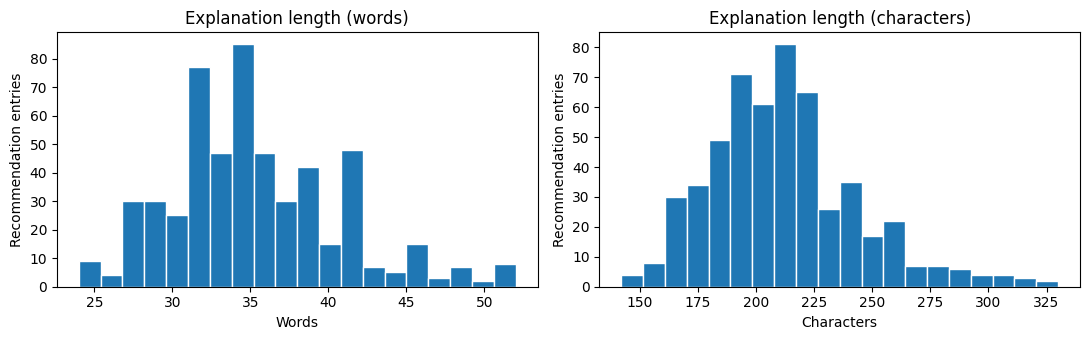

In [ ]:
# plot

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, column, label in zip(axes, ["word_count", "character_count"], ["Words", "Characters"]):
    ax.hist(analysis_df[column], bins=20, edgecolor="white")
    ax.set(xlabel=label, ylabel="Recommendation entries", title=f"Explanation length ({label.lower()})")
plt.tight_layout()
plt.show()

### c. Distribution of explanation types (ingredient-, nutrition-, taste-focused)

#### preprocessing for useful text (Run ONLY Once)

In [ ]:
%pip install -q spacy pyarrow
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [36]:
import re
import unicodedata
from pathlib import Path

import pandas as pd
import spacy


processed_dir = Path(
    "/content/drive/MyDrive/XFoodRec_Project_Data/processed"
)
processed_dir.mkdir(parents=True, exist_ok=True)

nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)


# Keep these words even when spaCy marks them as stopwords.
keep_stopwords = {
    # Negation
    "no", "not", "never", "neither", "nor", "without",
    "hardly", "barely", "rarely",

    # References to the user or item
    "you", "your", "yours", "yourself", "yourselves",
    "this", "that", "these", "those", "it",
    "they", "them", "their", "its",

    # Degree and quantity
    "very", "too", "enough", "more", "most", "less", "least",
    "extremely", "highly", "slightly", "moderately",
    "relatively", "especially", "particularly", "quite",
    "rather", "much", "many", "few", "little",
    "high", "low", "higher", "lower",

    # Modality and uncertainty
    "can", "could", "may", "might", "must", "should",
    "would", "possibly", "perhaps"
}


# Remove these from recipe ingredient text because they usually
# describe quantity or package size rather than the ingredient.
ingredient_quantity_terms = {
    "piece", "serving", "cup", "teaspoon", "tablespoon",
    "ounce", "pound", "gram", "kilogram", "milliliter",
    "liter", "package", "slice", "pinch", "dash"
}


# Standardize common units before joining them to numeric values.
unit_forms = {
    "gram": "g",
    "grams": "g",
    "milligram": "mg",
    "milligrams": "mg",
    "microgram": "mcg",
    "micrograms": "mcg",
    "kilogram": "kg",
    "kilograms": "kg",
    "milliliter": "ml",
    "milliliters": "ml",
    "liter": "l",
    "liters": "l",
    "ounce": "oz",
    "ounces": "oz",
    "pound": "lb",
    "pounds": "lb"
}


def normalize_text(value):
    """Normalize Unicode and spacing before tokenization."""
    if value is None:
        return ""

    if not isinstance(value, str):
        try:
            if pd.isna(value):
                return ""
        except (TypeError, ValueError):
            pass
        value = str(value)

    value = unicodedata.normalize("NFKC", value)
    value = (
        value.replace("’", "'")
        .replace("‘", "'")
        .replace("“", '"')
        .replace("”", '"')
        .replace("–", "-")
        .replace("—", "-")
    )
    return re.sub(r"\s+", " ", value).strip()


def is_number(value):
    """Check whether a token is a whole or decimal number."""
    return bool(re.fullmatch(r"\d+(?:\.\d+)?", value))


def combine_numbers_and_units(lemmas):
    """
    Combine values such as ['15', 'g'] into ['15g'].
    Combine type labels such as ['type', '1'] into ['type-1'].
    """
    combined = []
    i = 0

    while i < len(lemmas):
        current = lemmas[i]

        # Keep medical subtype expressions together.
        if (
            current == "type"
            and i + 1 < len(lemmas)
            and is_number(lemmas[i + 1])
        ):
            combined.append(f"type-{lemmas[i + 1]}")
            i += 2
            continue

        # Combine a number with a recognized measurement unit.
        if (
            is_number(current)
            and i + 1 < len(lemmas)
            and lemmas[i + 1] in unit_forms
        ):
            combined.append(
                current + unit_forms[lemmas[i + 1]]
            )
            i += 2
            continue

        # Keep percentage values together.
        if (
            is_number(current)
            and i + 1 < len(lemmas)
            and lemmas[i + 1] == "%"
        ):
            combined.append(current + "%")
            i += 2
            continue

        combined.append(current)
        i += 1

    return combined


def lemmatize_doc(
    doc,
    keep_numbers,
    remove_ingredient_quantities=False
):
    """Remove punctuation and ordinary stopwords, then lemmatize."""
    lemmas = []

    for token in doc:
        if token.is_space:
            continue

        # Handle percent before punctuation filtering.
        if token.text == "%":
            if keep_numbers:
                lemmas.append("%")
            continue

        # Keep numbers in explanations and persona text.
        if token.like_num:
            if keep_numbers:
                lemmas.append(token.text.lower())
            continue

        # Remove brackets, commas, hyphens, and other punctuation.
        if token.is_punct:
            continue

        surface = token.lower_

        # spaCy splits contractions such as "isn't" into "is" and "n't".
        if surface in {"n't", "n’t"}:
            lemmas.append("not")
            continue

        lemma = token.lemma_.lower().strip()
        if not lemma or lemma == "-pron-":
            lemma = surface

        # Keep alphanumeric names such as B12, even when recipe quantities
        # are removed.
        has_letters = any(character.isalpha() for character in token.text)
        has_digits = any(character.isdigit() for character in token.text)
        is_alphanumeric_name = has_letters and has_digits

        if (
            remove_ingredient_quantities
            and lemma in ingredient_quantity_terms
        ):
            continue

        if token.is_stop and lemma not in keep_stopwords:
            continue

        if token.is_alpha or is_alphanumeric_name or lemma in keep_stopwords:
            lemmas.append(lemma)

    return combine_numbers_and_units(lemmas)


def add_text_items(
    records,
    entity_id,
    source_field,
    value,
    lemma_column,
    keep_numbers,
    persona_id=None,
    recipe_id=None,
    rank=None,
    recommendation_id=None,
    remove_ingredient_quantities=False
):
    """Add one row per text item, such as one ingredient or tag."""
    if isinstance(value, (list, tuple)):
        items = list(enumerate(value))
    else:
        items = [(0, value)]

    for item_index, item in items:
        text = normalize_text(item)
        if not text:
            continue

        records.append({
            "document_id": (
                f"{entity_id}:{source_field}:{item_index}"
            ),
            "recommendation_id": recommendation_id,
            "persona_id": persona_id,
            "recipe_id": recipe_id,
            "rank": rank,
            "source_field": source_field,
            "item_index": item_index,
            "_text": text,
            "_lemma_column": lemma_column,
            "_keep_numbers": keep_numbers,
            "_remove_ingredient_quantities":
                remove_ingredient_quantities
        })


def make_lemma_table(records):
    """Save IDs, source field, and named lemma column; omit source text."""
    texts = [record["_text"] for record in records]
    docs = nlp.pipe(texts, batch_size=64)

    rows = []

    for record, doc in zip(records, docs):
        lemma_column = record["_lemma_column"]

        rows.append({
            "document_id": record["document_id"],
            "recommendation_id": record["recommendation_id"],
            "persona_id": record["persona_id"],
            "recipe_id": record["recipe_id"],
            "rank": record["rank"],
            "source_field": record["source_field"],
            "item_index": record["item_index"],
            lemma_column: lemmatize_doc(
                doc,
                keep_numbers=record["_keep_numbers"],
                remove_ingredient_quantities=(
                    record["_remove_ingredient_quantities"]
                )
            )
        })

    return pd.DataFrame(rows)

# One explanation row per recommendation.
explanation_records = []

for item in recommendations:
    persona_id = str(item["persona"]["id"])

    for rank, recommendation in enumerate(
        item["recommendations"],
        start=1
    ):
        recipe_id = str(recommendation["recipe_id"])
        recommendation_id = f"{persona_id}_rank_{rank:02d}"

        add_text_items(
            explanation_records,
            entity_id=recommendation_id,
            source_field="explanation",
            value=recommendation["explanation"],
            lemma_column="explanation_lemmas",
            keep_numbers=True,
            persona_id=persona_id,
            recipe_id=recipe_id,
            rank=rank,
            recommendation_id=recommendation_id
        )

# Recipe titles, ingredients, and tags.
recipe_records = []

for _, row in recipes.drop_duplicates("recipe_id").iterrows():
    recipe_id = str(row["recipe_id"])

    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_title",
        value=row["title"],
        lemma_column="recipe_text_lemmas",
        keep_numbers=True,
        recipe_id=recipe_id
    )

    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_ingredient",
        value=row["ingredients_title"],
        lemma_column="recipe_text_lemmas",
        keep_numbers=False,
        recipe_id=recipe_id,
        remove_ingredient_quantities=True
    )

    add_text_items(
        recipe_records,
        entity_id=recipe_id,
        source_field="recipe_tag",
        value=row["tags"],
        lemma_column="recipe_text_lemmas",
        keep_numbers=True,
        recipe_id=recipe_id
    )


# Persona descriptions, goals, preferences, restrictions, allergies,
# and health conditions.
persona_records = []

persona_fields = {
    "description": "persona_description",
    "profile.dietary_goal": "dietary_goal",
    "profile.dietaryProfile.dietaryRestrictions.selected":
        "dietary_restriction",
    "profile.dietaryProfile.dietaryRestrictions.other":
        "dietary_restriction_other",
    "profile.dietaryProfile.foodAllergies.selected":
        "food_allergy",
    "profile.dietaryProfile.foodAllergies.other":
        "food_allergy_other",
    "profile.dietaryProfile.healthConditions.selected":
        "health_condition",
    "profile.dietaryProfile.healthConditions.other":
        "health_condition_other",
    "profile.likedIngredients": "liked_ingredient",
    "profile.dislikedIngredients": "disliked_ingredient",
    "profile.favoriteCuisines": "favorite_cuisine"
}

for _, row in personas_df.iterrows():
    persona_id = str(row["id"])

    for column, source_field in persona_fields.items():
        add_text_items(
            persona_records,
            entity_id=persona_id,
            source_field=source_field,
            value=row[column],
            lemma_column="persona_text_lemmas",
            keep_numbers=True,
            persona_id=persona_id
        )


explanation_lemmas_df = make_lemma_table(explanation_records)
recipe_lemmas_df = make_lemma_table(recipe_records)
persona_lemmas_df = make_lemma_table(persona_records)

explanation_lemmas_df["rank"] = (
    explanation_lemmas_df["rank"].astype("Int64")
)

assert explanation_lemmas_df["recommendation_id"].is_unique
assert len(explanation_lemmas_df) == len(recommendations_df)

explanation_lemmas_df.to_parquet(
    processed_dir / "explanation_lemmas.parquet",
    index=False
)
recipe_lemmas_df.to_parquet(
    processed_dir / "recipe_lemmas.parquet",
    index=False
)
persona_lemmas_df.to_parquet(
    processed_dir / "persona_lemmas.parquet",
    index=False
)

print("Saved processed files to:", processed_dir)
print("Explanation records:", len(explanation_lemmas_df))
print("Recipe text items:", len(recipe_lemmas_df))
print("Persona text items:", len(persona_lemmas_df))

display(
    explanation_lemmas_df[
        [
            "recommendation_id",
            "persona_id",
            "recipe_id",
            "rank",
            "explanation_lemmas"
        ]
    ].head()
)

display(
    recipe_lemmas_df.loc[
        recipe_lemmas_df["source_field"].eq("recipe_ingredient"),
        ["recipe_id", "recipe_text_lemmas"]
    ].head()
)

Saved processed files to: /content/drive/MyDrive/XFoodRec_Project_Data/processed
Explanation records: 536
Recipe text items: 2106
Persona text items: 530


,recommendation_id,persona_id,recipe_id,rank,explanation_lemmas
0,user_01_rank_01,user_01,81968,1,"[chickpea, spinach, greek, fantastic, choice, ..."
1,user_01_rank_02,user_01,10614,2,"[refried, beans, offer, high, protein, content..."
2,user_01_rank_03,user_01,94673,3,"[egyptian, red, lentil, soup, rich, protein, f..."
3,user_01_rank_04,user_01,364252,4,"[favorite, sauteed, kale, nutrient, dense, opt..."
4,user_01_rank_05,user_01,12569,5,"[hearty, black, beans, rice, combine, protein,..."


,recipe_id,recipe_text_lemmas
1,113861,"[cub, steak, oil, butter, flour, salt, onion, ..."
4,111212,"[lea, perrins, worcestershire, sauce, lea, per..."
7,497021,"[lean, beef, coleslaw, mix, cabbage, carrot, s..."
10,31184,"[extra, virgin, olive, oil, onion, clove, garl..."
13,71739,"[olive, oil, onion, garlic, clove, long, grain..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


#### Load processed data (DO this to CONTINUE analysis NO need run ALL cells)

In [37]:
processed_dir = Path("/content/drive/MyDrive/XFoodRec_Project_Data/processed")

recommendation_tokens_df = pd.read_parquet(processed_dir / "recommendation_tokens.parquet")
recipe_tokens_df = pd.read_parquet(processed_dir / "recipe_tokens.parquet")
persona_tokens_df = pd.read_parquet(processed_dir / "persona_tokens.parquet")

print("Explanations:", len(recommendation_tokens_df))
print("Recipe text items:", len(recipe_tokens_df))
print("Persona text items:", len(persona_tokens_df))

Explanations: 536
Recipe text items: 2106
Persona text items: 530


In [ ]:
def normalize_text(text):
    return re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()

def without_title(text, title):
    text = normalize_text(text)
    title = normalize_text(title)
    return re.sub(r"(?<!\w)" + re.escape(title) + r"(?!\w)", " ", text) if title else text

def matched_terms(text, terms):
    return sorted({term for term in terms if re.search(
        r"(?<!\w)" + re.escape(normalize_text(term)) + r"(?!\w)", text
    )})

ingredient_terms = """ingredient ingredients chicken beef pork bacon turkey lamb fish salmon tuna shrimp
seafood egg eggs milk cheese yogurt butter cream tofu tempeh seitan soy lentil lentils
chickpea chickpeas bean beans legume legumes pea peas rice quinoa oat oats wheat barley
bread pasta noodle noodles potato potatoes spinach kale cabbage broccoli carrot carrots
tomato tomatoes onion onions garlic pepper peppers mushroom mushrooms eggplant zucchini
vegetable vegetables veggie veggies fruit fruits apple apples banana bananas berry berries
lemon lime avocado nut nuts peanut peanuts almond almonds walnut walnuts seed seeds
hemp tahini oil olive coconut corn flour sugar honey herb herbs spice spices cinnamon
cumin turmeric cilantro parsley basil oregano chocolate cocoa salt ginger mustard""".split()

nutrition_terms = """protein proteins carbohydrate carbohydrates carb carbs fat fats fiber fibre
calorie calories vitamin vitamins mineral minerals sodium sugar sugars cholesterol
nutrient nutrients nutritious nutrition antioxidant antioxidants omega""".split() + [
    "nutrient dense", "energy dense", "low gi", "glycemic", "glycaemic"
]

taste_terms = """taste tasty flavor flavors flavour flavours delicious savory savoury sweet sweetness
spicy spice spiced tangy creamy crunchy crispy tender juicy aromatic refreshing hearty
satisfying flavorful flavourful mild bitter sour smoky texture textures""".split()

type_lexicons = {
    "ingredient_focused": ingredient_terms,
    "nutrition_focused": nutrition_terms,
    "taste_focused": taste_terms
}

analysis_df["classification_text"] = analysis_df.apply(
    lambda row: without_title(row["explanation"], row["title"]), axis=1
)

for label, terms in type_lexicons.items():
    analysis_df[label + "_matches"] = analysis_df["classification_text"].map(
        lambda text: matched_terms(text, terms)
    )
    analysis_df[label] = analysis_df[label + "_matches"].map(bool)

type_columns = list(type_lexicons)
analysis_df["unclassified"] = ~analysis_df[type_columns].any(axis=1)
type_summary = analysis_df[type_columns + ["unclassified"]].sum().rename("count").to_frame()
type_summary["percent"] = (100 * type_summary["count"] / len(analysis_df)).round(2)
display(type_summary)

analysis_df["type_combination"] = analysis_df[type_columns].apply(
    lambda row: " + ".join(label.replace("_focused", "") for label in type_columns if row[label]) or "unclassified",
    axis=1
)
type_combinations = analysis_df["type_combination"].value_counts().rename("count").to_frame()
type_combinations["percent"] = (100 * type_combinations["count"] / len(analysis_df)).round(2)
display(type_combinations)

,count,percent
ingredient_focused,374,69.78
nutrition_focused,505,94.22
taste_focused,383,71.46
unclassified,4,0.75


,count,percent
type_combination,,
ingredient + nutrition + taste,247,46.08
nutrition + taste,118,22.01
ingredient + nutrition,102,19.03
nutrition,38,7.09
ingredient + taste,16,2.99
ingredient,9,1.68
unclassified,4,0.75
taste,2,0.37


### d. Coverage of user preferences vs. health justification

In [ ]:
persona_lookup = {persona["id"]: persona["profile"] for persona in personas}

preference_pattern = re.compile(
    r"\b(?:your (?:\w+ ){0,3}(?:preferences?|taste|tastes|palate|liking|love|fondness|favorites?|favourites?)"
    r"|you (?:\w+ ){0,2}(?:enjoy|like|love|prefer)"
    r"|(?:preferences?|taste|palate) for)\b"
)
user_cue_pattern = re.compile(r"\b(?:you|your)\b")
health_pattern = re.compile(
    r"\b(?:healthy|health|healthier|heart healthy|blood sugar|blood pressure|glycemic|glycaemic"
    r"|weight loss|weight management|lose weight|muscle gain|muscle building|lean bulking"
    r"|recovery|digestion|digestive|immunity|immune|hydration|bone health"
    r"|energy boost|energy levels|sustained energy|active lifestyle"
    r"|gluten free|dairy free|lactose free|nut free|vegan|vegetarian|keto"
    r"|allergy|allergies|allergen|allergens|diabetes|diabetic|celiac|hypertension)\b"
)
nutrient_pattern = r"(?:protein|carbs?|carbohydrates?|fats?|fiber|fibre|calories?|vitamins?|minerals?|sodium|sugars?|cholesterol|nutrients?|antioxidants?)"
nutrient_claim_pattern = re.compile(
    r"\b(?:high|low|rich|packed|good source|good amount|excellent source|provides?|providing|contains?|containing)\b"
    r"(?:\s+\w+){0,4}\s+" + nutrient_pattern + r"\b"
    r"|\b" + nutrient_pattern + r"\s+(?:rich|packed|dense)\b"
)

def classify_coverage(row):
    profile = persona_lookup.get(row["persona_id"], {})
    preference_terms = (profile.get("likedIngredients", []) + profile.get("dislikedIngredients", [])
                        + profile.get("favoriteCuisines", []))
    diet_profile = profile.get("dietaryProfile", {})
    health_terms = [profile.get("dietary_goal", "")]
    for field in ["dietaryRestrictions", "foodAllergies", "healthConditions"]:
        health_terms += diet_profile.get(field, {}).get("selected", [])
    # Avoid treating generic goal labels or a food-allergen name by itself as a health rationale.
    health_terms = [term for term in health_terms if term and term not in ["Maintenance", "Food Allergy"]]
    preference_evidence, health_evidence = [], []
    for sentence in re.split(r"(?<=[.!?])\s+", row["explanation"]):
        text = without_title(sentence, row["title"])
        preference_evidence += [match.group() for match in preference_pattern.finditer(text)]
        if user_cue_pattern.search(text):
            preference_evidence += ["persona preference: " + term for term in matched_terms(text, preference_terms)]
        health_evidence += [match.group() for match in health_pattern.finditer(text)]
        health_evidence += [match.group() for match in nutrient_claim_pattern.finditer(text)]
        # Require context for persona-specific conditions, restrictions and goals.
        if re.search(r"\b(?:your|goal|needs|diet|condition|manage|management|avoid|free|allergy|allergies)\b", text):
            health_evidence += ["persona health/diet: " + term for term in matched_terms(text, health_terms)]
    return pd.Series({
        "preference_evidence": sorted(set(preference_evidence)),
        "health_evidence": sorted(set(health_evidence))
    })

coverage_evidence = analysis_df.apply(classify_coverage, axis=1)
analysis_df[coverage_evidence.columns] = coverage_evidence
analysis_df["preference_covered"] = analysis_df["preference_evidence"].map(bool)
analysis_df["health_justification"] = analysis_df["health_evidence"].map(bool)
analysis_df["coverage_group"] = np.select(
    [analysis_df["preference_covered"] & analysis_df["health_justification"],
     analysis_df["preference_covered"], analysis_df["health_justification"]],
    ["Both", "Preference only", "Health only"], default="Neither"
)
coverage_summary = analysis_df["coverage_group"].value_counts().reindex(
    ["Preference only", "Health only", "Both", "Neither"], fill_value=0
).rename("count").to_frame()
coverage_summary["percent"] = (100 * coverage_summary["count"] / len(analysis_df)).round(2)
display(coverage_summary)

coverage_totals = analysis_df[["preference_covered", "health_justification"]].sum().rename("count").to_frame()
coverage_totals["percent"] = (100 * coverage_totals["count"] / len(analysis_df)).round(2)
display(coverage_totals)

,count,percent
coverage_group,,
Preference only,68,12.69
Health only,190,35.45
Both,236,44.03
Neither,42,7.84


,count,percent
preference_covered,304,56.72
health_justification,426,79.48
